In [3]:
# ===============================================================
# Import Libraries
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects
from linearmodels.panel import compare
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
from linearmodels.panel.data import PanelData
from scipy.stats.mstats import winsorize
import scipy.stats as st
from scipy import stats
from datetime import datetime, timedelta
import warnings
import re 
import statsmodels.discrete.discrete_model as smd
import statsmodels.genmod.generalized_linear_model as smg

# --- > Import for linearmodels results <---
from linearmodels.panel.results import PanelEffectsResults

# Set plot style for better readability
plt.style.use('seaborn-v0_8-whitegrid') # Use a modern seaborn style
sns.set_palette('Set2') # Set a nice color palette
plt.rcParams['figure.figsize'] = (15, 7)  # Default figure size
plt.rcParams['font.size'] = 12 # Default font size
plt.rcParams['axes.titlesize'] = 16 # Title font size
plt.rcParams['axes.labelsize'] = 14 # Axis label font size
plt.rcParams['xtick.labelsize'] = 12 # X-tick label size
plt.rcParams['ytick.labelsize'] = 12 # Y-tick label size
plt.rcParams['legend.fontsize'] = 12 # Legend font size


# ===============================================================
# Helper Functions
# ===============================================================

def significance(p):
    """Returns significance stars based on p-value."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

def display_regression_results(res, model_name, decimals=4):
    """Displays regression results in a structured format."""
    print("=" * 70)
    print(f"{model_name} - Panel Regression Results")
    print("=" * 70)
    try:
        print(f"Number of observations: {int(res.nobs)}") # Ensure nobs is integer
    except:
        print("Number of observations: N/A") # Handle cases where nobs might be missing
    try:
        print(f"R-squared (Within): {res.rsquared_within:.{decimals}f}")
    except AttributeError:
         try:
             print(f"R-squared: {res.rsquared:.{decimals}f}") # For non-PanelOLS models like GLM/Logit
         except AttributeError:
            print("R-squared: N/A")

    print("\nFull Summary:")
    # Use display from IPython if available for better formatting, otherwise print
    try:
        from IPython.display import display
        display(res.summary)
    except ImportError:
        print(res.summary)

    # Create DataFrame with results for non-absorbed parameters
    try:
        if len(res.params) > 0:
            # Ensure indices are clean strings
            param_index = [str(idx) for idx in res.params.index]

            results_df = pd.DataFrame({
                'Variable': param_index,
                'Coefficient': res.params.values,
                'Std Err': res.std_errors.values,
                'T-stat': res.tstats.values,
                'P-value': res.pvalues.values
            })
            # Apply rounding after calculations
            results_df[['Coefficient', 'Std Err', 'P-value']] = results_df[['Coefficient', 'Std Err', 'P-value']].round(decimals)
            results_df['T-stat'] = results_df['T-stat'].round(2)
            results_df['Significance'] = results_df['P-value'].apply(significance)
            # Handle potential multi-index before sorting
            if isinstance(results_df['Variable'], pd.MultiIndex):
                 results_df.index = results_df['Variable'].astype(str) # Convert MultiIndex to string index

            # Sort by P-value
            results_df_sorted = results_df.sort_values('P-value')

            print("\nSignificance Analysis (Sorted by P-value):")
            # Use display from IPython if available
            try:
                from IPython.display import display
                display(results_df_sorted)
            except ImportError:
                print(results_df_sorted.to_string()) # Use to_string for better console output
        else:
            print("No parameters estimated (potentially all absorbed by fixed effects or model failed).")
    except Exception as e:
        print(f"Error creating significance analysis table: {e}")
        # Print basic parameters if available
        try:
            print("\nEstimated Parameters (Basic):")
            print(res.params)
        except:
            print("Could not retrieve basic parameters.")


def remove_edges(group, n=30):
    """
    Removes 'n' observations around opening/closing markers within each group.
    Sorts by 'datetime'. Identifies 'IsOpeningOrClosing == 1'.
    For even occurrences (0, 2, ...): Removes that observation and the next n-1.
    For odd occurrences (1, 3, ...): Removes that observation and the previous n-1.
    """
    group_sorted = group.sort_values("datetime")
    idx_to_remove = set()

    # Reset index to easily get positions, keep original index in 'index' column
    group_reset = group_sorted.reset_index()
    occ_positions = group_reset.index[group_reset["IsOpeningOrClosing"] == 1].tolist()

    num_obs = len(group_reset)

    for i, pos in enumerate(occ_positions):
        if i % 2 == 0: # Even occurrence (opening)
            # Remove from 'pos' up to 'pos + n - 1'
            start_remove = pos
            end_remove = min(pos + n, num_obs) # Ensure not exceeding group bounds
            removal_range = range(start_remove, end_remove)
        else: # Odd occurrence (closing)
            # Remove from 'pos - n + 1' up to 'pos'
            start_remove = max(0, pos - n + 1) # Ensure not going below 0
            end_remove = pos + 1
            removal_range = range(start_remove, end_remove)

        # Get original indices to remove from the sorted group
        original_indices = group_reset.loc[list(removal_range), 'index'].tolist()
        idx_to_remove.update(original_indices)

    # Drop using the original index values stored in idx_to_remove
    return group_sorted.drop(index=list(idx_to_remove))

def timestamp_to_HHMM(ts_val):
    """Converts a timestamp value (potentially int or string) to HH:MM format."""
    try:
        ts_str = str(int(ts_val)).zfill(8)  # Ensure integer, convert to string, pad
        hour = ts_str[0:2]
        minute = ts_str[2:4]
        return f"{hour}:{minute}"
    except (ValueError, TypeError):
        return None # Return None if conversion fails

In [4]:
# ===============================================================
# Step 1: Load and Prepare Data (Drive-aware; inline download)
# ===============================================================
from __future__ import annotations

import sys, os, json, shutil
from pathlib import Path
import pandas as pd

# 0) Locate project root (folder that contains src/config.py) and expose it
PROJECT_ROOT = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "src" / "config.py").exists():
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    raise ModuleNotFoundError("Could not locate project root containing src/config.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Make sure DATA_ROOT points to the project's data folder (so prefer_sample_path resolves correctly)
os.environ["DATA_ROOT"] = str(PROJECT_ROOT / "data")

from src.config import prefer_sample_path, path

print("Step 1: Loading and Preparing Data...")
print("Using DATA_ROOT =", os.environ["DATA_ROOT"])

# 1) Resolve expected CSVs (prefer sample/ then raw/)
ta35_csv  = prefer_sample_path("ta35_with_alerts.csv")
order_csv = prefer_sample_path("order_book_ta125.csv")
print("Resolved paths:", ta35_csv, "|", order_csv)

# 2) If files are missing locally, pull them from your Google Drive folder (inline, no subprocess)
if not (Path(ta35_csv).exists() and Path(order_csv).exists()):
    print("Local data not found. Downloading from Google Drive...")

    # Ensure gdown is available in THIS interpreter
    try:
        import gdown  # type: ignore
    except Exception:
        import subprocess as _sp
        _sp.check_call([sys.executable, "-m", "pip", "install", "gdown>=4.7", "pyyaml>=6.0"])
        import gdown  # type: ignore

    RAW = PROJECT_ROOT / "data" / "raw"
    RAW.mkdir(parents=True, exist_ok=True)
    tmp_folder = RAW / "_tmp_drive_folder"
    if tmp_folder.exists():
        shutil.rmtree(tmp_folder)
    tmp_folder.mkdir(parents=True, exist_ok=True)

    DRIVE_FOLDER_LINK = "https://drive.google.com/drive/folders/1zjoXQJ2mYFPmvN9xoVEadCqrPHBcM9aG?usp=drive_link"
    print("Downloading folder (this may take a few minutes)...")
    gdown.download_folder(url=DRIVE_FOLDER_LINK, output=str(tmp_folder), quiet=False, use_cookies=False)

    # Locate required CSVs and copy them into canonical names under data/raw/
    ob_candidates = {"order_book_ta125.csv", "order_book.csv", "orderbook.csv"}
    al_candidates = {"ta35_with_alerts.csv", "alerts.csv"}

    found_ob = None
    found_al = None
    for root, _, files in os.walk(tmp_folder):
        for f in files:
            fl = f.lower()
            if found_ob is None and fl in {x.lower() for x in ob_candidates}:
                found_ob = Path(root) / f
            if found_al is None and fl in {x.lower() for x in al_candidates}:
                found_al = Path(root) / f

    if found_ob:
        shutil.copy(found_ob, RAW / "order_book_ta125.csv")
        print("Saved:", RAW / "order_book_ta125.csv")
    else:
        print("Warning: could not find an order-book CSV in the Drive folder.")

    if found_al:
        shutil.copy(found_al, RAW / "ta35_with_alerts.csv")
        print("Saved:", RAW / "ta35_with_alerts.csv")
    else:
        print("Warning: could not find an alerts CSV in the Drive folder.")

    # Cleanup temp and re-resolve paths now that files exist under DATA_ROOT
    shutil.rmtree(tmp_folder, ignore_errors=True)
    ta35_csv  = prefer_sample_path("ta35_with_alerts.csv")
    order_csv = prefer_sample_path("order_book_ta125.csv")
    print("Resolved after download:", ta35_csv, "|", order_csv)

# 3) Load (your original logic)
try:
    ta35_data = pd.read_csv(ta35_csv)
    order_book_ta125 = pd.read_csv(order_csv)
    print(f"Loaded TA35 data: {ta35_data.shape}")
    print(f"Loaded Order Book data: {order_book_ta125.shape}")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Make sure the Drive folder link is accessible and contains the expected CSV names.")
    raise

# 4) Create 'datetime' if missing (unchanged)
if "datetime" not in ta35_data.columns:
    try:
        ta35_data["Date"] = pd.to_datetime(ta35_data["Date"], format="%d/%m/%Y", errors='coerce')
        ta35_data["Time_str"] = ta35_data["Time"].astype(str)
        ta35_data["Time_str_padded"] = ta35_data["Time_str"].str.zfill(6)
        ta35_data["Time_timedelta"] = pd.to_timedelta(
            ta35_data["Time_str_padded"].str[:2] + ':' +
            ta35_data["Time_str_padded"].str[2:4] + ':' +
            ta35_data["Time_str_padded"].str[4:6],
            errors='coerce'
        )
        ta35_data["datetime"] = ta35_data["Date"] + ta35_data["Time_timedelta"]
        ta35_data = ta35_data.drop(columns=["Time_str", "Time_str_padded", "Time_timedelta"])
        print("Created 'datetime' column in ta35_data.")
    except Exception as e:
        print(f"Error creating 'datetime' in ta35_data: {e}")
        print("Please check 'Date' and 'Time' column formats.")

# 5) Final coercion + filter order book (unchanged)
ta35_data["datetime"] = pd.to_datetime(ta35_data["datetime"], errors="coerce")
symbols_ta35 = ta35_data["Symbol"].unique()
order_book_ta35 = order_book_ta125[order_book_ta125["StockSymbol"].isin(symbols_ta35)].copy()
print(f"Filtered Order Book for TA35 symbols: {order_book_ta35.shape}")


Step 1: Loading and Preparing Data...
Using DATA_ROOT = c:\Users\Hagai-BY\TASE-Red-Alert-Impact-1\data
Resolved paths: c:\Users\Hagai-BY\TASE-Red-Alert-Impact-1\data\raw\ta35_with_alerts.csv | c:\Users\Hagai-BY\TASE-Red-Alert-Impact-1\data\raw\order_book_ta125.csv
Loaded TA35 data: (954262, 29)
Loaded Order Book data: (6855969, 10)
Filtered Order Book for TA35 symbols: (3966498, 10)


In [5]:
# SIMPLE RETURN  :  (P_t / P_{t-1}) - 1
ta35_data['Return'] = (
    ta35_data
    .groupby('Rank')['ClosePrice']        
    .pct_change()                      
)

In [6]:
# ===============================================================
# Step 2: Process Order Book Data - Classify Investors and Aggregate Volume
# ===============================================================
print("\nStep 2: Processing Order Book Data...")

# Define threshold for institutional investor classification
institutional_threshold = 1_300_000

# Classify buyers and sellers based on order sequence value
order_book_ta35["Buyer_Type"] = np.where(
    pd.to_numeric(order_book_ta35["Buyer_Order_Sequence"], errors='coerce') >= institutional_threshold,
    "Institutional", "Private"
)
order_book_ta35["Seller_Type"] = np.where(
    pd.to_numeric(order_book_ta35["Seller_Order_Sequence"], errors='coerce') >= institutional_threshold,
    "Institutional", "Private"
)

# Convert timestamp to datetime
order_book_ta35["Date"] = pd.to_datetime(order_book_ta35["Date"], format="%Y-%m-%d", errors='coerce')
order_book_ta35["Time_HHMM"] = order_book_ta35["TimeStamp"].apply(timestamp_to_HHMM)
order_book_ta35["datetime"] = pd.to_datetime(
    order_book_ta35["Date"].dt.strftime("%Y-%m-%d") + " " + order_book_ta35["Time_HHMM"],
    format="%Y-%m-%d %H:%M", errors='coerce'
)

# Drop rows where datetime conversion failed
order_book_ta35.dropna(subset=["datetime"], inplace=True)

# Set datetime index and get minute-level timestamp
order_book_ta35 = order_book_ta35.set_index("datetime")
order_book_ta35["datetime_minute"] = order_book_ta35.index.floor("T")

# Ensure Turnover_NIS is numeric
order_book_ta35["Turnover_NIS"] = pd.to_numeric(order_book_ta35["Turnover_NIS"], errors='coerce').fillna(0)

# Create volume columns based on investor type
order_book_ta35["Buyer_Ins_Vol"] = np.where(order_book_ta35["Buyer_Type"] == "Institutional", order_book_ta35["Turnover_NIS"], 0)
order_book_ta35["Buyer_Priv_Vol"] = np.where(order_book_ta35["Buyer_Type"] == "Private", order_book_ta35["Turnover_NIS"], 0)
order_book_ta35["Seller_Ins_Vol"] = np.where(order_book_ta35["Seller_Type"] == "Institutional", order_book_ta35["Turnover_NIS"], 0)
order_book_ta35["Seller_Priv_Vol"] = np.where(order_book_ta35["Seller_Type"] == "Private", order_book_ta35["Turnover_NIS"], 0)

# Aggregate volumes by stock and minute
grouped_vol = order_book_ta35.groupby(["StockSymbol", "datetime_minute"]).agg(
    Buyer_Ins_Vol_sum=("Buyer_Ins_Vol", "sum"),
    Buyer_Priv_Vol_sum=("Buyer_Priv_Vol", "sum"),
    Seller_Ins_Vol_sum=("Seller_Ins_Vol", "sum"),
    Seller_Priv_Vol_sum=("Seller_Priv_Vol", "sum")
).reset_index()

# Rename columns for merging
grouped_vol.rename(columns={
    "StockSymbol": "Symbol",
    "datetime_minute": "datetime"
}, inplace=True)

# Convert datetime column in grouped_vol to datetime objects for merging
grouped_vol["datetime"] = pd.to_datetime(grouped_vol["datetime"], errors='coerce')



Step 2: Processing Order Book Data...


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\216278187.py:32: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  order_book_ta35["datetime_minute"] = order_book_ta35.index.floor("T")


In [7]:
# ===============================================================
# Step 3: Merge Aggregated Volumes with TA35 Data
# ===============================================================
print("\nStep 3: Merging Aggregated Volumes...")

# Ensure datetime in ta35_data is datetime object
ta35_data["datetime"] = pd.to_datetime(ta35_data["datetime"], errors='coerce')

# Perform the merge
ta35_merged = pd.merge(
    ta35_data,
    grouped_vol,
    on=["Symbol", "datetime"],
    how="left" # Use left merge to keep all ta35_data rows
)

# Fill NaN values in the newly merged volume columns with 0
vol_sum_cols = ["Buyer_Ins_Vol_sum", "Buyer_Priv_Vol_sum", "Seller_Ins_Vol_sum", "Seller_Priv_Vol_sum"]
for col in vol_sum_cols:
    if col in ta35_merged.columns:
        ta35_merged[col] = ta35_merged[col].fillna(0)

print(f"Merged data shape: {ta35_merged.shape}")
print("Columns after merge:", ta35_merged.columns.tolist())

# --- > ADDITION: Create TOTAL Institutional and Private Volumes <---
ta35_merged['Total_Ins_Vol_sum'] = ta35_merged['Buyer_Ins_Vol_sum'] + ta35_merged['Seller_Ins_Vol_sum']
ta35_merged['Total_Priv_Vol_sum'] = ta35_merged['Buyer_Priv_Vol_sum'] + ta35_merged['Seller_Priv_Vol_sum']
ta35_merged["Turnover_NIS"] = (ta35_merged["Total_Ins_Vol_sum"] + ta35_merged["Total_Priv_Vol_sum"]) / 2

ta35_merged['Refined_Ins_Vol'] = ta35_merged[['Buyer_Ins_Vol_sum', 'Seller_Ins_Vol_sum']].max(axis=1)
ta35_merged['Refined_Priv_Vol'] = ta35_merged[['Buyer_Priv_Vol_sum', 'Seller_Priv_Vol_sum']].max(axis=1)

print("Created 'Total_Ins_Vol_sum' and 'Total_Priv_Vol_sum' columns.")



Step 3: Merging Aggregated Volumes...
Merged data shape: (954262, 33)
Columns after merge: ['Date', 'Time', 'ID', 'MarketNumber', 'Symbol', 'OpenPrice', 'ClosePrice', 'HighPrice', 'LowPrice', 'Volume', 'Turnover', 'NumTrades', 'Return', 'Rank', 'IsOpeningOrClosing', 'ta125_index', 'ta35_index', 'exclude_flag', 'datetime', 'Num_Alerts', 'redalert_1', 'redalert_2', 'redalert_3', 'redalert_4', 'redalert_5', 'redalert_6', 'redalert_7', 'redalert_8', 'Turnover_NIS', 'Buyer_Ins_Vol_sum', 'Buyer_Priv_Vol_sum', 'Seller_Ins_Vol_sum', 'Seller_Priv_Vol_sum']
Created 'Total_Ins_Vol_sum' and 'Total_Priv_Vol_sum' columns.


In [8]:
# ===============================================================
# Step 5: Filter Data - Remove Opening/Closing Periods
# ===============================================================
print("\nStep 5: Filtering Data (Removing Opening/Closing Periods)...")

# Add TradeDay column if it doesn't exist
if 'TradeDay' not in ta35_merged.columns:
    ta35_merged['TradeDay'] = ta35_merged['datetime'].dt.date

# Ensure 'IsOpeningOrClosing' column exists, create if not (assuming it's based on time)
# Example: Define opening/closing times (adjust as per market rules)
opening_time_start = pd.to_datetime("09:45:00").time()
opening_time_end = pd.to_datetime("10:15:00").time() # e.g., first 30 mins after open
closing_time_start = pd.to_datetime("17:00:00").time() # e.g., last 30 mins before close
closing_time_end = pd.to_datetime("17:30:00").time()

if 'IsOpeningOrClosing' not in ta35_merged.columns:
    print("Creating 'IsOpeningOrClosing' column based on time windows...")
    ta35_merged['time_only'] = ta35_merged['datetime'].dt.time
    ta35_merged['IsOpeningOrClosing'] = np.where(
        (ta35_merged['time_only'] >= opening_time_start) & (ta35_merged['time_only'] <= opening_time_end) |
        (ta35_merged['time_only'] >= closing_time_start) & (ta35_merged['time_only'] <= closing_time_end),
        1, 0
    )
    ta35_merged.drop(columns=['time_only'], inplace=True)
    print("'IsOpeningOrClosing' column created.")


# Sort data before applying the filter
ta35_merged = ta35_merged.sort_values(['Symbol', 'datetime'])

# Apply the remove_edges function
try:
    # Ensure TradeDay is suitable for grouping (e.g., string or date object)
    ta35_merged['TradeDay'] = ta35_merged['datetime'].dt.strftime('%Y-%m-%d')
    ta35_filtered = ta35_merged.groupby(['Symbol', 'TradeDay'], group_keys=False).apply(remove_edges, n=30)
    print(f"Original number of rows: {len(ta35_merged)}")
    print(f"Number of rows after removing edges: {len(ta35_filtered)}")
except KeyError as e:
     print(f"KeyError during edge removal: {e}. Check if 'Symbol' or 'TradeDay' exists.")
     ta35_filtered = ta35_merged.copy() # Continue without filtering if error occurs
except Exception as e:
     print(f"An unexpected error occurred during edge removal: {e}")
     ta35_filtered = ta35_merged.copy()


Step 5: Filtering Data (Removing Opening/Closing Periods)...
Original number of rows: 954262
Number of rows after removing edges: 815662


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\748230134.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ta35_filtered = ta35_merged.groupby(['Symbol', 'TradeDay'], group_keys=False).apply(remove_edges, n=30)


In [9]:
# ===============================================================
# Step X: Create ±15-minute dummy variables around ALL overlapping alerts
# ===============================================================

# 1) Identify every column that represents an alert window (columns start with 'redalert_')
red_cols = [c for c in ta35_filtered.columns if c.startswith("redalert_")]

if not red_cols:
    raise ValueError(
        "No 'redalert_*' columns found – make sure they exist before creating dummies."
    )

# 2) Offsets we want to convert into dummies:  -15…-1 , 0.1 (the alert minute) , +1…+15
offsets = list(range(-15, 0)) + [0.1] + list(range(1, 16))   # total = 31 values

for off in offsets:
    # Build a nice column name: dummy_-14, dummy_+5, dummy_alert, …
    if off == 0.1:
        col_name = "dummy_alert"
    else:
        sign = "+" if off > 0 else ""
        col_name = f"dummy_{sign}{int(off)}"

    # 3) Create the dummy:
    #    1  → if at least ONE of the redalert_* columns equals `off` at this row
    #    0  → otherwise
    ta35_filtered[col_name] = (
        (ta35_filtered[red_cols] == off).any(axis=1).astype(int)
    )

# 4) Drop one dummy column (here: dummy_-15) to avoid the “dummy trap”
ta35_filtered.drop(columns=["dummy_-15"], inplace=True, errors="ignore")

print(
    "Finished creating alert-window dummies (±15 minutes plus alert).",
    "\nAdded columns:",
    [c for c in ta35_filtered.columns if c.startswith("dummy_")]
)


Finished creating alert-window dummies (±15 minutes plus alert). 
Added columns: ['dummy_-14', 'dummy_-13', 'dummy_-12', 'dummy_-11', 'dummy_-10', 'dummy_-9', 'dummy_-8', 'dummy_-7', 'dummy_-6', 'dummy_-5', 'dummy_-4', 'dummy_-3', 'dummy_-2', 'dummy_-1', 'dummy_alert', 'dummy_+1', 'dummy_+2', 'dummy_+3', 'dummy_+4', 'dummy_+5', 'dummy_+6', 'dummy_+7', 'dummy_+8', 'dummy_+9', 'dummy_+10', 'dummy_+11', 'dummy_+12', 'dummy_+13', 'dummy_+14', 'dummy_+15']


In [10]:
# =======================================================================================
# STEP 1  ──  Build one-minute TOTAL turnover for all 35 stocks  (unchanged)
# =======================================================================================
df = ta35_filtered.copy()
df['datetime_min'] = df['datetime'].dt.floor('T')

tot = (df.groupby('datetime_min')['Turnover_NIS']          # Σ 35 stocks
          .sum()
          .rename('TotTurnover_NIS')
          .to_frame())

# keep 0 ₪ for missing minutes  → continuous minute grid
full_idx = pd.date_range(tot.index.min(), tot.index.max(), freq='T')
tot      = tot.reindex(full_idx, fill_value=0)

# =======================================================================================
# STEP 2  ──  Detect daily trading window **directly from LUMI** and
#             keep only minutes between the day’s “first” and “last” trade
# =======================================================================================

# ―― 2-a)  LUMI rows with a positive turnover  ―-----------------------------------------
lumi = (ta35_filtered
        .loc[ta35_filtered['Symbol'] == 'LUMI',
             ['datetime', 'Turnover_NIS']]
        .copy())
lumi['datetime_min'] = lumi['datetime'].dt.floor('T')

# ―― 2-b)  For every calendar-date: first & last trade-minute  ―---------------------------
daily_window = (lumi
                .groupby(lumi['datetime_min'].dt.date)['datetime_min']
                .agg(open_dt='min', close_dt='max')        # timestamps!
                .rename_axis('date'))

# preview
print(daily_window.head())
#   date        open_dt                close_dt
#   2024-03-17   2024-03-17 09:45:00    2024-03-17 17:25:00
#   …

# ―― 2-c)  Boolean mask: “inside trading window of that day”  ―---------------------------
# turn lookup-table into Series of tuples  (open-time, close-time)
win_dict = daily_window.apply(lambda r: (r.open_dt.time(), r.close_dt.time()), axis=1).to_dict()

def in_window(ts):
    d = ts.date()
    if d not in win_dict:
        return False                         # a weekend / holiday with no LUMI trades
    t_open, t_close = win_dict[d]
    return t_open <= ts.time() <= t_close

mask = pd.Series(tot.index.map(in_window), index=tot.index)

tot_trading = tot[mask].copy()

print(f"Minutes kept : {mask.sum():,}")
print(f"Minutes drop : {(~mask).sum():,}")



                       open_dt            close_dt
date                                              
2023-10-01 2023-10-01 10:29:00 2023-10-01 13:54:00
2023-10-02 2023-10-02 10:29:00 2023-10-02 13:54:00
2023-10-03 2023-10-03 10:29:00 2023-10-03 13:54:00
2023-10-04 2023-10-04 10:29:00 2023-10-04 13:54:00
2023-10-05 2023-10-05 10:29:00 2023-10-05 13:54:00
Minutes kept : 23,308
Minutes drop : 108,023


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\2814659363.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['datetime_min'] = df['datetime'].dt.floor('T')
C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\2814659363.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(tot.index.min(), tot.index.max(), freq='T')
C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\2814659363.py:26: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  lumi['datetime_min'] = lumi['datetime'].dt.floor('T')


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\3679989437.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .dt.floor('T')                     # align to minute
C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\3679989437.py:31: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  tot_trading.index.floor('10T')      # 09:07 → 09:00  |  09:19 → 09:10


Total Turnover – OLS-HAC (clean trading window)
                            OLS Regression Results                            
Dep. Variable:        TotTurnover_log   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     26.28
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:05:48   Log-Likelihood:                -24009.
No. Observations:               23308   AIC:                         4.829e+04
Df Residuals:                   23173   BIC:                         4.938e+04
Df Model:                         134                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cons

,coef,se,t,p,sig
d_-14,-0.0261,0.0621,-0.42,0.6741,
d_-13,0.0639,0.0701,0.91,0.3621,
d_-12,0.0405,0.0630,0.64,0.5204,
d_-11,-0.0473,0.0618,-0.77,0.4438,
d_-10,-0.1431,0.0633,-2.26,0.0239,*
d_-9,0.0415,0.0634,0.66,0.5123,
d_-8,0.0572,0.0569,1.01,0.3142,
d_-7,-0.0012,0.0618,-0.02,0.9846,
d_-6,0.0058,0.0683,0.08,0.9328,
d_-5,0.0243,0.0613,0.40,0.6922,


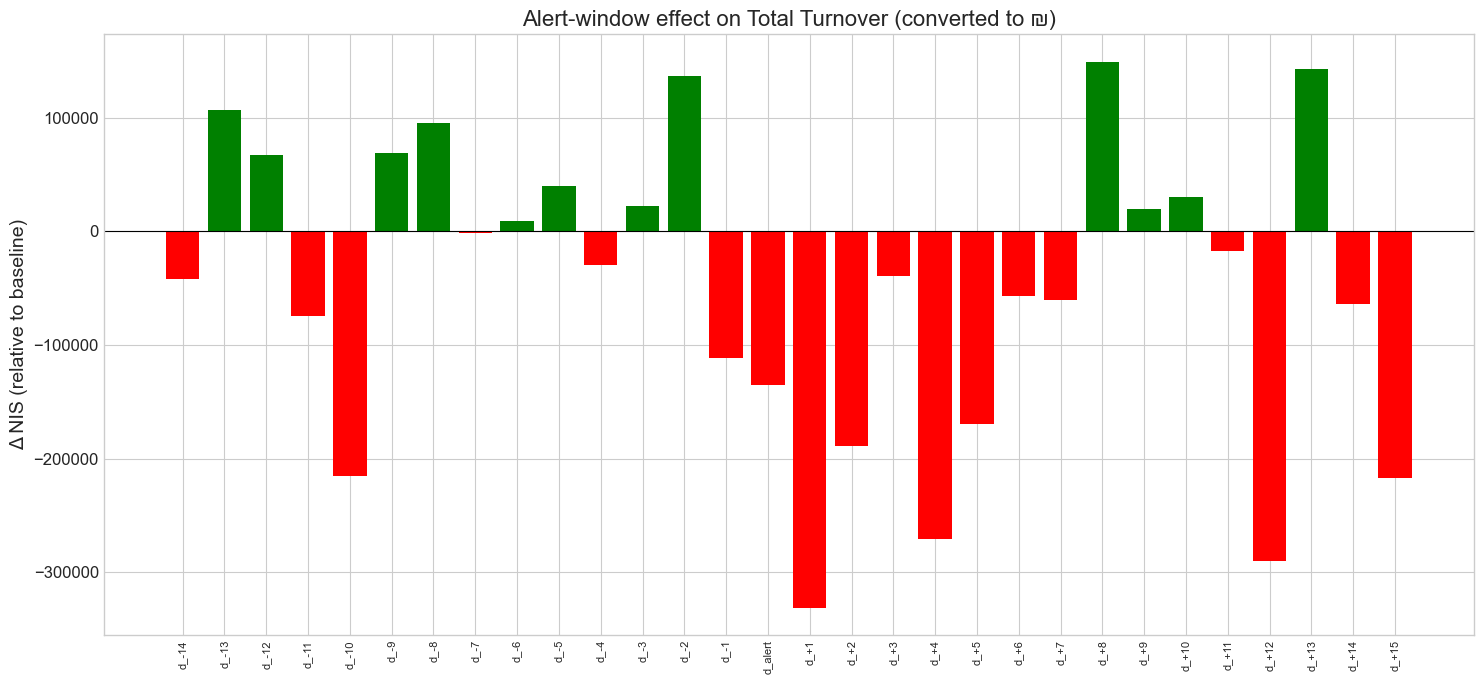

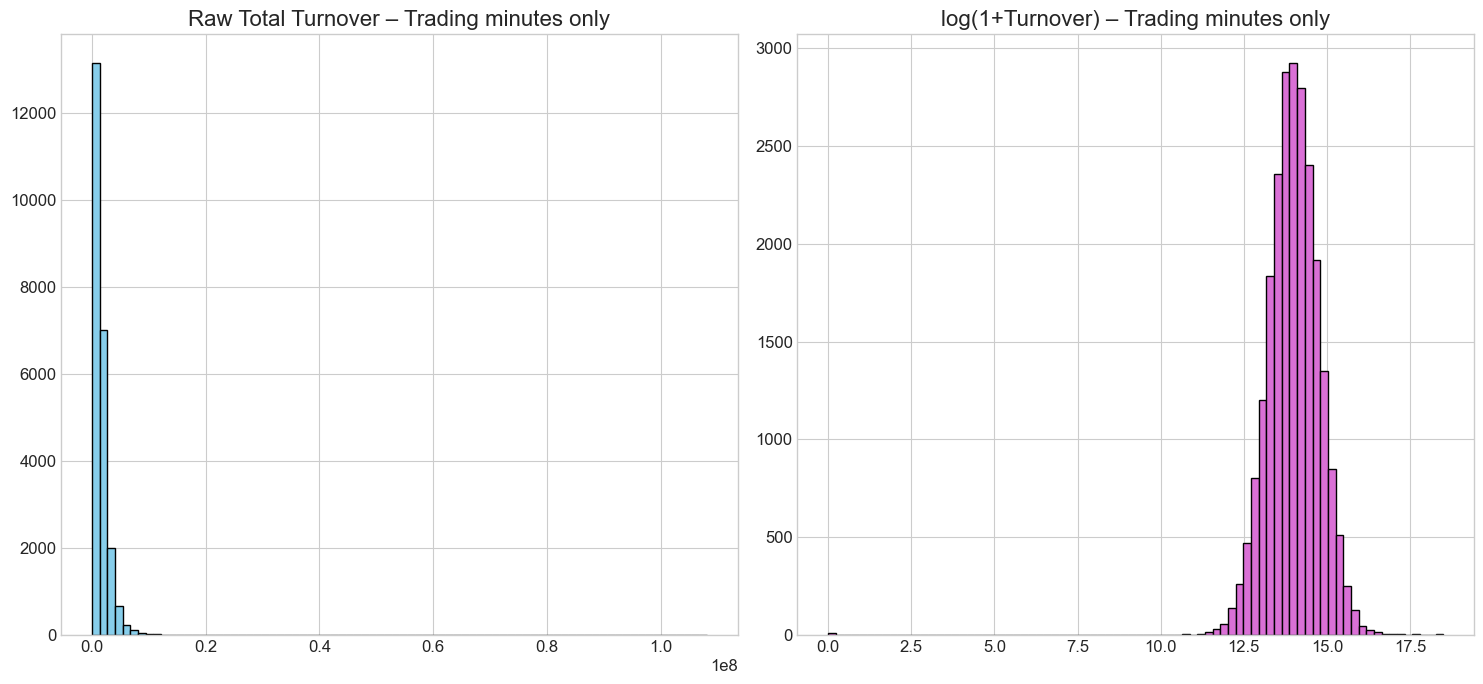

In [11]:
# =======================================================================================
# STEP 3 ── Alert-window dummies on the cleaned minute index
# =======================================================================================

# 3-a) locate exact alert times (t = 0) from the original minute grid
alert_times = (ta35_filtered
               .loc[ta35_filtered['dummy_alert'] == 1, 'datetime']
               .dt.floor('T')                     # align to minute
               .unique())

# 3-b) create empty dummies on tot_trading
for k in range(-15, 16):
    col = 'd_alert' if k == 0 else f'd_{k:+d}'
    tot_trading[col] = 0                          # initialise with zeros

# 3-c) flag the relevant minutes
for t0 in alert_times:
    for k in range(-15, 16):
        idx = t0 + pd.Timedelta(minutes=k)
        if idx in tot_trading.index:
            col = 'd_alert' if k == 0 else f'd_{k:+d}'
            tot_trading.at[idx, col] = 1

# =======================================================================================
# STEP 4 ── Fixed-Effects
# =======================================================================================

# --- 4-a) Time-of-day FE (minute-of-day) ----------------------------------------------
# 1) 
tot_trading['hhmm10'] = (
    tot_trading.index.floor('10T')      # 09:07 → 09:00  |  09:19 → 09:10
                 .strftime('%H:%M')     # "09:00", "09:10", …
)

# 2) לבנות Fixed Effects של “דקת-10-ביום”
timeFE = pd.get_dummies(tot_trading['hhmm10'],
                        drop_first=True,  
                        dtype=int)

# --- 4-b) Date FE (trading date)  ------------------------------------------------------
tot_trading['date'] = tot_trading.index.date
dateFE  = pd.get_dummies(tot_trading['date'], drop_first=True, dtype=int)

# =======================================================================================
# STEP 5 ── log(1+x) transform
# =======================================================================================
tot_trading['TotTurnover_log'] = np.log1p(tot_trading['TotTurnover_NIS'])
mu_raw = tot_trading['TotTurnover_NIS'].mean()     # needed for back-transform

# =======================================================================================
# STEP 6 ── Build X-matrix  &  OLS-HAC (maxlags = 40 ≈ 40 minutes)
# =======================================================================================
alertFE = tot_trading.filter(like='d_').drop(columns='d_-15')
X       = pd.concat([timeFE, dateFE, alertFE], axis=1).astype(float)
X_const = sm.add_constant(X, has_constant='add')

y = tot_trading['TotTurnover_log']

ols_res = sm.OLS(y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 40})

# =======================================================================================
# STEP 7 ── Nicely print results  (patch to work with statsmodels)
# =======================================================================================

def display_regression_results_generic(res, title, decimals=4):
    print("="*75, f"\n{title}\n", "="*75, sep='')
    try:
        print(res.summary())
    except Exception:
        print(res)

    # quick significance table (only the alert dummies)
    se  = res.bse
    t   = res.tvalues
    p   = res.pvalues
    params = res.params

    sub = pd.DataFrame({
        'coef': params.round(decimals),
        'se'  : se.round(decimals),
        't'   : t.round(2),
        'p'   : p.round(decimals)
    }).loc[alertFE.columns]          # only d_-15 … d_alert … d_+15

    sub['sig'] = sub['p'].apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '')
    display(sub)

display_regression_results_generic(ols_res, "Total Turnover – OLS-HAC (clean trading window)")

# =======================================================================================
# STEP 8 ── Convert log-β back to ₪  and plot bar-chart
# =======================================================================================
beta_log = ols_res.params[alertFE.columns]
beta_nis = np.expm1(beta_log.values) * (mu_raw + 1)

cols   = alertFE.columns.tolist()
x      = np.arange(len(cols))
colors = ['green' if v >= 0 else 'red' for v in beta_nis]

plt.figure(figsize=(15,7))
plt.bar(x, beta_nis, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, cols, rotation=90, fontsize=8)
plt.ylabel("Δ NIS (relative to baseline)")
plt.title("Alert-window effect on Total Turnover (converted to ₪)")
plt.tight_layout()
plt.show()

# =======================================================================================
# STEP 9 ── Histograms: raw vs log(1+x)
# =======================================================================================
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.hist(tot_trading['TotTurnover_NIS'], bins=80, color='skyblue', edgecolor='k')
plt.title("Raw Total Turnover – Trading minutes only")
plt.subplot(1,2,2)
plt.hist(tot_trading['TotTurnover_log'], bins=80, color='orchid', edgecolor='k')
plt.title("log(1+Turnover) – Trading minutes only")
plt.tight_layout()
plt.show()


,avg_NIS
minute,
-14,1890502.0
-13,1968829.0
-12,1814302.0
-11,1633380.0
-10,1537363.0
-9,1774309.0
-8,1847515.0
-7,1864507.0
-6,1898094.0


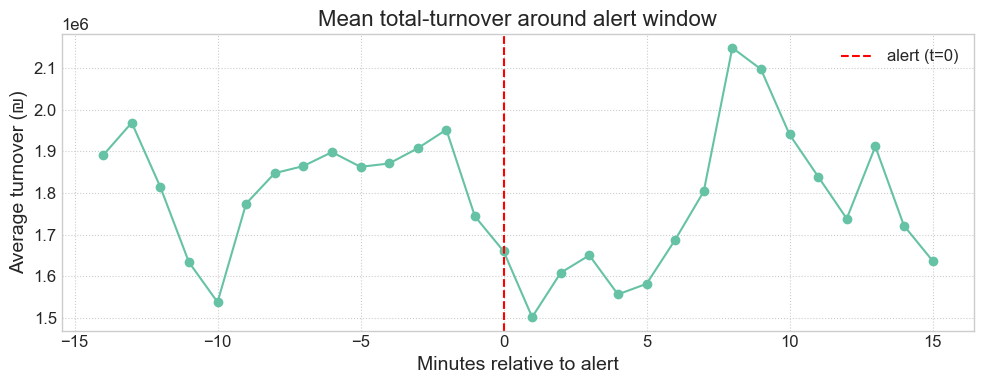

In [12]:
# --------------------------------------------------------------
# Average / median turnover for each relative-minute dummy
# --------------------------------------------------------------
stat_f = np.mean          # או  np.median  np.std  וכו'

rows = []
for col in alertFE.columns:                 # d_-15 … d_alert … d_+15
    k    = 0           if col == 'd_alert' else int(col.replace('d_',''))
    mask = tot_trading[col] == 1            # הדקה הזו באירוע
    avg  = stat_f(tot_trading.loc[mask, 'TotTurnover_NIS'])
    rows.append((k, avg))

turnover_stats = (pd.DataFrame(rows, columns=['minute','avg_NIS'])
                    .sort_values('minute')
                    .set_index('minute'))

display(turnover_stats.round(0))            # טבלה יפה
plt.figure(figsize=(10,4))
plt.plot(turnover_stats.index, turnover_stats['avg_NIS'],
         marker='o', lw=1.5)
plt.axvline(0, color='red', ls='--', label='alert (t=0)')
plt.grid(True, ls=':')
plt.ylabel('Average turnover (₪)')
plt.xlabel('Minutes relative to alert')
plt.title('Mean total-turnover around alert window')
plt.tight_layout(); plt.legend(); plt.show()


Total Turnover – OLS-HAC - Panel Regression Results
Number of observations: 23308
R-squared: 0.2889

Full Summary:


<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x0000023567126FD0>>

Error creating significance analysis table: 'OLSResults' object has no attribute 'std_errors'

Estimated Parameters (Basic):
const    14.033054
10:30    -0.048417
10:31    -0.060570
10:32    -0.177484
10:33    -0.024396
           ...    
d_+11    -0.009295
d_+12    -0.221171
d_+13     0.091298
d_+14    -0.029515
d_+15    -0.141385
Length: 481, dtype: float64


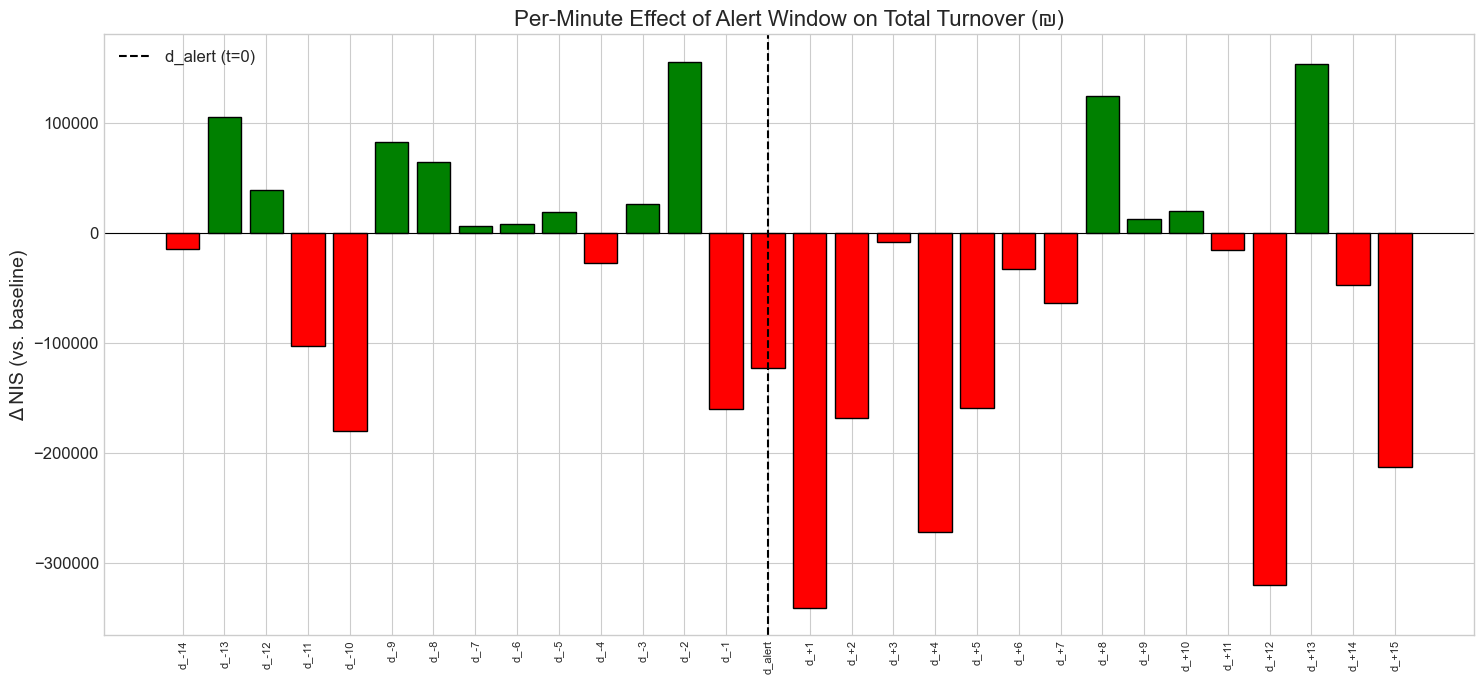

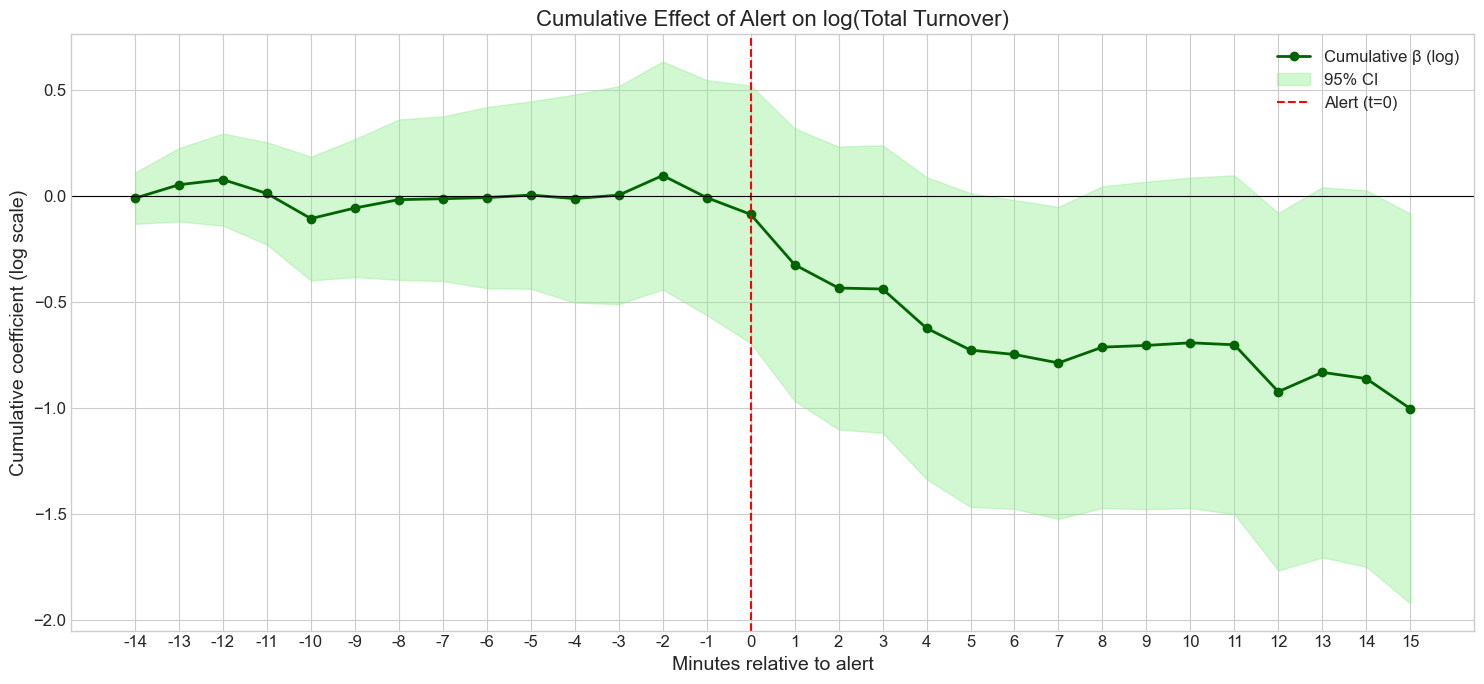

In [13]:
# =======================================================================================
# STEP 3 ──  Time-of-Day FE  +  Date FE  +  Alert-Dummies
# =======================================================================================

# ----- 3-a)  intraday seasonality  ------------------------------------------------------
tot_trading['hhmm'] = tot_trading.index.strftime('%H:%M')
timeFE   = pd.get_dummies(tot_trading['hhmm'], drop_first=True, dtype=int)

# ----- 3-b)  Date fixed-effects  ---------------------------------------------------------
tot_trading['date'] = tot_trading.index.date
dateFE   = pd.get_dummies(tot_trading['date'], drop_first=True, dtype=int)

# ----- 3-c)  Alert window dummies  ------------------------------------------------------
alertFE = tot_trading.filter(like='d_').drop(columns='d_-15')

# combine
X        = pd.concat([timeFE, dateFE, alertFE], axis=1).astype(float)
X_const  = sm.add_constant(X, has_constant='add')

# =======================================================================================
# STEP 4 ──  Response = log(1 + Total Turnover)
# =======================================================================================
tot_trading['TotTurnover_log'] = np.log1p(tot_trading['TotTurnover_NIS'])
y = tot_trading['TotTurnover_log']
mu_raw = tot_trading['TotTurnover_NIS'].mean()     # needed to back-transform β

# =======================================================================================
# STEP 5 ──  OLS with Newey–West HAC (40 lags ≈ 40 minutes)
# =======================================================================================
ols_res = sm.OLS(y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 40})
display_regression_results(ols_res, "Total Turnover – OLS-HAC")

# =======================================================================================
# STEP 6 ──  β of alert dummies  →  Δ NIS  +  Bar-Chart
# =======================================================================================
beta_log  = ols_res.params[alertFE.columns]
beta_nis  = np.expm1(beta_log.values) * (mu_raw + 1)                 # back-transform
colors    = ['green' if b >= 0 else 'red' for b in beta_nis]
x         = np.arange(len(beta_nis))

plt.figure(figsize=(15,7))
plt.bar(x, beta_nis, color=colors, edgecolor='k')
idx0 = list(alertFE.columns).index('d_alert')
plt.axvline(idx0, color='black', linestyle='--', lw=1.5, label='d_alert (t=0)')
plt.axhline(0, color='black', lw=.8)
plt.xticks(x, alertFE.columns, rotation=90, fontsize=8)
plt.ylabel("Δ NIS (vs. baseline)")
plt.title("Per-Minute Effect of Alert Window on Total Turnover (₪)")
plt.legend(); plt.tight_layout(); plt.show()

# =======================================================================================
# STEP 7 ──  Cumulative-Effect Plot  (sum of β up to each minute)  + 95 % CI
# =======================================================================================

# ---- 7-a)  order dummies chronologically ----------------------------------------------
def time_from_name(name):
    if name == 'd_alert': return 0
    return int(name.replace('d_',''))
ordered = sorted(alertFE.columns, key=time_from_name)
times   = [time_from_name(c) for c in ordered]

# ---- 7-b)  cumulative β ---------------------------------------------------------------
beta_vec = beta_log[ordered].values
cum_beta = np.cumsum(beta_vec)

# ---- 7-c)  cumulative standard error  --------------------------------------------------
cov = ols_res.cov_params().loc[ordered, ordered]      # HAC covariance of dummies
cum_se = []
for i in range(len(ordered)):
    sub = cov.iloc[:i+1, :i+1]
    var = sub.to_numpy().sum()                        # var(sum) = ΣΣ cov_ij
    cum_se.append(np.sqrt(var))
cum_se  = np.array(cum_se)
ci_mult = 1.96                                        # 95 %
lower   = cum_beta - ci_mult*cum_se
upper   = cum_beta + ci_mult*cum_se

# ---- 7-d)  plot  -----------------------------------------------------------------------
plt.figure(figsize=(15,7))
plt.plot(times, cum_beta, color='darkgreen', marker='o', lw=2, label='Cumulative β (log)')
plt.fill_between(times, lower, upper, color='lightgreen', alpha=.4, label='95% CI')
plt.axvline(0, color='red', ls='--', lw=1.5, label='Alert (t=0)')
plt.axhline(0, color='black', lw=.8)
plt.xticks(times, times)                    # show every integer tick
plt.xlabel("Minutes relative to alert")
plt.ylabel("Cumulative coefficient (log scale)")
plt.title("Cumulative Effect of Alert on log(Total Turnover)")
plt.legend(); plt.tight_layout(); plt.show()


30 30


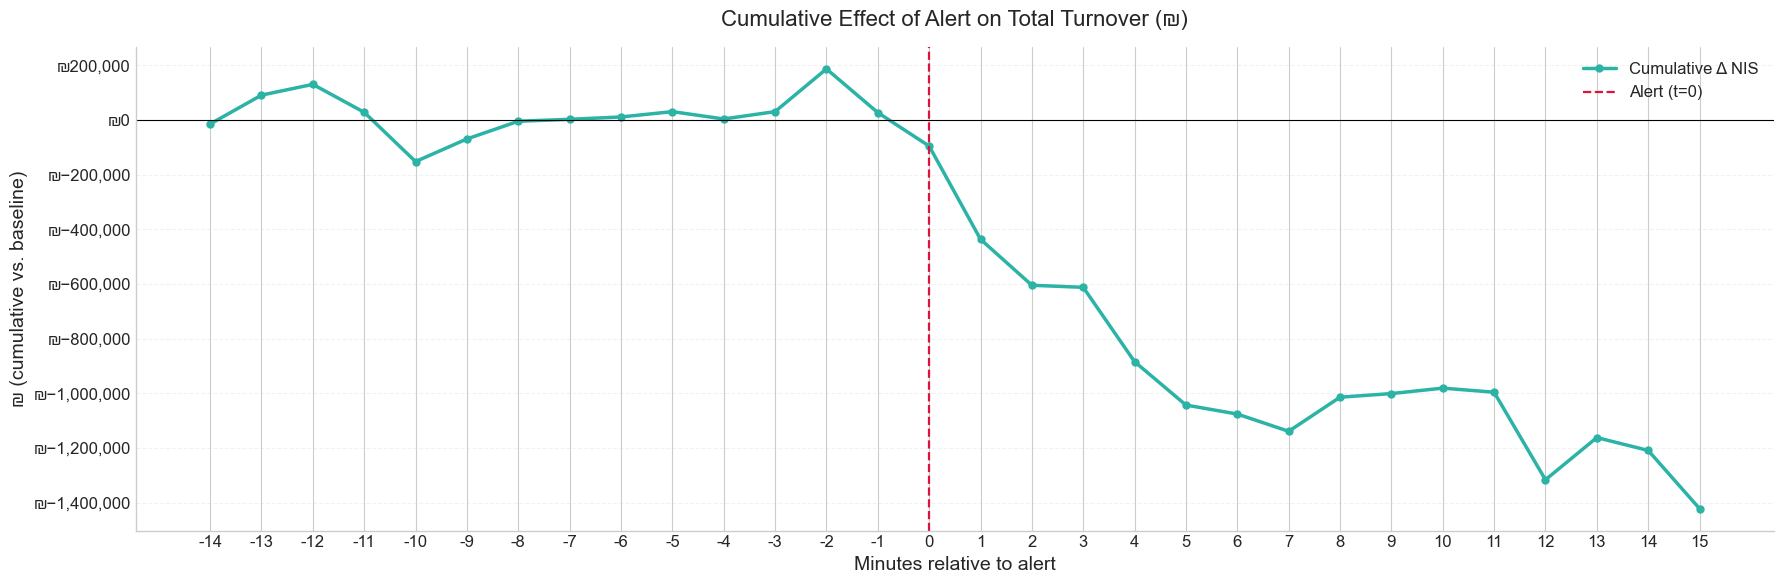

In [14]:
# ---------------------------------
# 1) Chronological ordering of dummy variables
# ---------------------------------
ordered = sorted(alertFE.columns, key=time_from_name)  # k = -15 … +15
times   = [time_from_name(c) for c in ordered]         # [-15, …, +15]

# ---------------------------------
# 2) Coefficients converted to NIS
# ---------------------------------
beta_nis = np.expm1(beta_log[ordered].values) * (mu_raw + 1)

# ---------------------------------
# 3) Cumulative sum in NIS  →  cum_nis
# ---------------------------------
cum_nis = np.cumsum(beta_nis)   # 31 values – one per minute

print(len(times), len(cum_nis))  # should print: 31 31

# ---------------------------------
# 4) Plot
# ---------------------------------
import matplotlib.ticker as mtick
plt.figure(figsize=(18, 6))

plt.plot(times, cum_nis, color='#2bb3a6', marker='o',
         linewidth=2.5, markersize=5, label='Cumulative Δ NIS')

plt.axvline(0, color='crimson', ls='--', lw=1.6, label='Alert (t=0)')
plt.axhline(0, color='black',  lw=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.25)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('₪{x:,.0f}'))

plt.xticks(times, times)
plt.xlabel("Minutes relative to alert")
plt.ylabel("₪ (cumulative vs. baseline)")
plt.title("Cumulative Effect of Alert on Total Turnover (₪)", pad=15)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


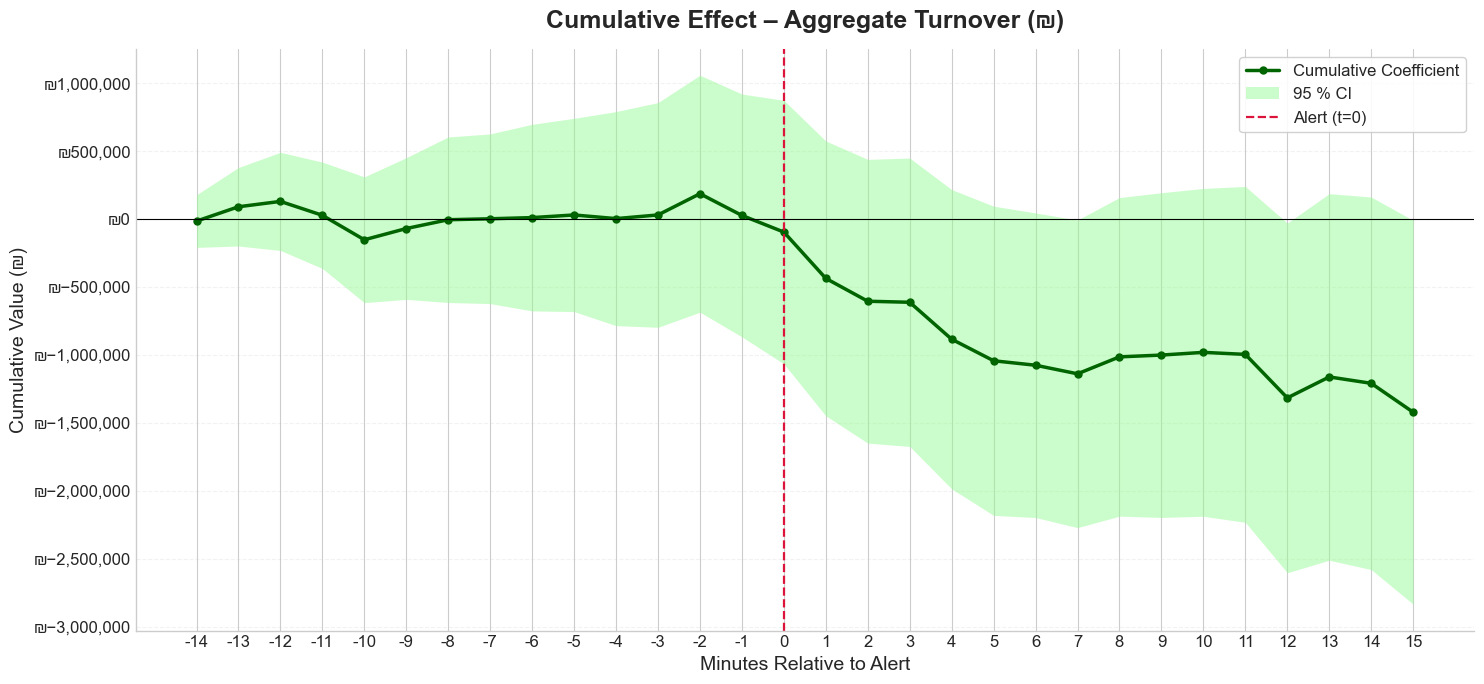

In [15]:
# =====================================================================
# 1)   cov(log-β)  →  cov(Δ NIS)   via a diagonal Jacobian
# =====================================================================
cov_log   = ols_res.cov_params().loc[ordered, ordered].values     
deriv_fac = np.exp(beta_log[ordered].values) * (mu_raw + 1)       
D         = np.diag(deriv_fac)                                    
cov_nis   = D @ cov_log @ D                                       

# =====================================================================
# 2)   Cumulative variance at each minute  →  cum_se
# =====================================================================
cum_var = []
for k in range(len(ordered)):                 
    sub = cov_nis[:k+1, :k+1]                
    cum_var.append(sub.sum())                
cum_se = np.sqrt(cum_var)                    

# 95 % confidence band
ci_mult = 1.96
lower   = cum_nis - ci_mult * cum_se
upper   = cum_nis + ci_mult * cum_se

# =====================================================================
# 3)   Plot with confidence ribbon
# =====================================================================
import matplotlib.ticker as mtick
plt.figure(figsize=(15, 7))

line_color = '#006400'   # DarkGreen
ci_color   = '#98fb98'   # PaleGreen

plt.plot(times, cum_nis, color=line_color, marker='o',
         linewidth=2.5, markersize=5,
         label='Cumulative Coefficient')

plt.fill_between(times, lower, upper,
                 facecolor=ci_color, alpha=0.5,
                 edgecolor=ci_color, linewidth=0,
                 label='95 % CI')

plt.axvline(0, color='crimson', ls='--', lw=1.6, label='Alert (t=0)')
plt.axhline(0, color='black',  lw=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.25)

# --- updated title / labels ---
plt.title("Cumulative Effect – Aggregate Turnover (₪)", pad=15, fontsize=18, weight='bold')
plt.ylabel("Cumulative Value (₪)")

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('₪{x:,.0f}'))
plt.xticks(times, times)
plt.xlabel("Minutes Relative to Alert")

for s in ['top', 'right']:
    plt.gca().spines[s].set_visible(False)

plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


In [16]:
# ===============================================================
# Manual Wald–F tests for five alert-time blocks
# ===============================================================
# ----- 1) define the five blocks --------------------------------
blocks = {
    "Pre-Alert (-14…-2)"   : range(-14, -1),
    "Around Alert (-1 0 +1)": [-1, 0, 1],
    "Post-Alert (+2…+5)"   : range( 2,  6),
    "Post-Alert (+6…+10)"  : range( 6, 11),
    "Post-Alert (+11…+15)" : range(11, 16),
}

rows = []
for name, ks in blocks.items():

    # Build the column names for this block
    coeffs = ["d_alert" if k == 0 else f"d_{k:+d}" for k in ks]

    # Skip the block if any coefficient is missing in the model
    if not set(coeffs).issubset(ols_res.params.index):
        print(f"{name}: at least one coefficient missing – skipped.")
        continue

    beta = ols_res.params.loc[coeffs].values.reshape(-1, 1)      # q × 1
    cov  = ols_res.cov_params().loc[coeffs, coeffs].values       # q × q

    # Skip if the covariance matrix is singular
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        print(f"{name}: covariance singular – skipped.")
        continue

    W = float(beta.T @ inv_cov @ beta)                           # χ²(q)
    q = len(coeffs)
    F = W / q                                                    # F(q, df_resid)
    p = 1 - st.f.cdf(F, q, ols_res.df_resid)

    rows.append({
        "Group"  : name,
        "df"     : f"{q}, {int(ols_res.df_resid)}",
        "F-stat" : round(F, 2),
        "p-value": round(p, 4)
    })

# ----- 2) show results ------------------------------------------
if rows:
    display(pd.DataFrame(rows).set_index("Group"))
else:
    print("No valid Wald tests could be computed.")


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\2438664024.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W = float(beta.T @ inv_cov @ beta)                           # χ²(q)
C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\2438664024.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W = float(beta.T @ inv_cov @ beta)                           # χ²(q)
C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_34588\2438664024.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprec

,df,F-stat,p-value
Group,,,
Pre-Alert (-14…-2),"13, 22827",0.98,0.4645
Around Alert (-1 0 +1),"3, 22827",4.55,0.0034
Post-Alert (+2…+5),"4, 22827",2.45,0.0437
Post-Alert (+6…+10),"5, 22827",0.59,0.7100
Post-Alert (+11…+15),"5, 22827",1.47,0.1946
